In [1]:
import time
import os
import random
import numpy as np     
import math

import matplotlib.pyplot as plt                                   
import autograd, autograd.core, autograd.extend, autograd.tracer  
import autograd.numpy as anp      
import scipy, scipy.ndimage, scipy.sparse, scipy.sparse.linalg 

from deap import base
from deap import creator
from deap import tools

import random
import matplotlib.pyplot as plt
import seaborn as sns

import sys
import numpy as np
from mpl_toolkits.mplot3d import Axes3D


import gym
from gymnasium import spaces

from stable_baselines3 import PPO, A2C
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results, ts2xy
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common import results_plotter

from scipy.ndimage import rotate
from pathos.multiprocessing import ProcessingPool as Pool

In [2]:
sys.path.append('../../../../../ocean_intella/ocean_intella/pipelay_profile_optimization/')

In [3]:
import elitism

In [4]:
from scipy.spatial import ConvexHull

In [5]:
import networkx as nx

In [6]:
x0, y0 = 17, 17

# FEM Model

In [7]:
class ObjectView(object):
    def __init__(self, d): self.__dict__ = d
    
def get_args(normals, forces, density=1e-4):  # Manage the problem setup parameters
    width = normals.shape[0] - 1
    height = normals.shape[1] - 1
    fixdofs = np.flatnonzero(normals.ravel())
    alldofs = np.arange(2 * (width + 1) * (height + 1))
    freedofs = np.sort(list(set(alldofs) - set(fixdofs)))
    params = {
      # material properties
      'young': 1, 'young_min': 1e-9, 'poisson': 0.3, 'g': 0,
      # constraints
      'density': density, 'xmin': 0.001, 'xmax': 1.0,
      # input parameters
      'nelx': width, 'nely': height, 'mask': 1, 'penal': 3.0, 'filter_width': 1,
      'freedofs': freedofs, 'fixdofs': fixdofs, 'forces': forces.ravel(),
      # optimization parameters
      'opt_steps': 80, 'print_every': 10}
    return ObjectView(params)

def mbb_beam(width=y0, height=x0, density=1e-4, y=1, x=0, rd=-1):  # textbook beam example
    normals = np.zeros((width + 1, height + 1, 2))
    normals[0, 0, x] = 1
    normals[0, 0, y] = 1
    normals[0, -1, x] = 1
    normals[0, -1, y] = 1
    forces = np.zeros((width + 1, height + 1, 2))
    forces[-1, rd, y] = -1
    return normals, forces, density

In [8]:
def young_modulus(x, e_0, e_min, p=3):
    return e_min + x ** p * (e_0 - e_min)

def physical_density(x, args, volume_contraint=False, use_filter=True):
    x = args.mask * x.reshape(args.nely, args.nelx)  # reshape from 1D to 2D
    return gaussian_filter(x, args.filter_width) if use_filter else x  # maybe filter

def mean_density(x, args, volume_contraint=False, use_filter=True):
    return anp.mean(physical_density(x, args, volume_contraint, use_filter)) / anp.mean(args.mask)

In [9]:
def objective(x, args, volume_contraint=False, use_filter=True):
    kwargs = dict(penal=args.penal, e_min=args.young_min, e_0=args.young)
    x_phys = physical_density(x, args, volume_contraint=volume_contraint, use_filter=use_filter)
    ke     = get_stiffness_matrix(args.young, args.poisson)  # stiffness matrix
    u      = displace(x_phys, ke, args.forces, args.freedofs, args.fixdofs, **kwargs)
    c      = compliance(x_phys, u, ke, **kwargs)
    return c

In [10]:
@autograd.extend.primitive
def gaussian_filter(x, width): # 2D gaussian blur/filter
    return scipy.ndimage.gaussian_filter(x, width, mode='reflect')

def _gaussian_filter_vjp(ans, x, width): # gives the gradient of orig. function w.r.t. x
    del ans, x  # unused
    return lambda g: gaussian_filter(g, width)
autograd.extend.defvjp(gaussian_filter, _gaussian_filter_vjp)

In [11]:
def compliance(x_phys, u, ke, *, penal=3, e_min=1e-9, e_0=1):
    nely, nelx = x_phys.shape
    ely, elx = anp.meshgrid(range(nely), range(nelx))  # x, y coords for the index map

    n1 = (nely+1)*(elx+0) + (ely+0)  # nodes
    n2 = (nely+1)*(elx+1) + (ely+0)
    n3 = (nely+1)*(elx+1) + (ely+1)
    n4 = (nely+1)*(elx+0) + (ely+1)
    all_ixs = anp.array([2*n1, 2*n1+1, 2*n2, 2*n2+1, 2*n3, 2*n3+1, 2*n4, 2*n4+1])
    u_selected = u[all_ixs]  # select from u matrix

    ke_u = anp.einsum('ij,jkl->ikl', ke, u_selected)  # compute x^penal * U.T @ ke @ U
    ce = anp.einsum('ijk,ijk->jk', u_selected, ke_u)
    C = young_modulus(x_phys, e_0, e_min, p=penal) * ce.T
    return anp.sum(C)

def get_stiffness_matrix(e, nu):  # e=young's modulus, nu=poisson coefficient
    k = anp.array([1/2-nu/6, 1/8+nu/8, -1/4-nu/12, -1/8+3*nu/8,
                -1/4+nu/12, -1/8-nu/8, nu/6, 1/8-3*nu/8])
    return e/(1-nu**2)*anp.array([[k[0], k[1], k[2], k[3], k[4], k[5], k[6], k[7]],
                               [k[1], k[0], k[7], k[6], k[5], k[4], k[3], k[2]],
                               [k[2], k[7], k[0], k[5], k[6], k[3], k[4], k[1]],
                               [k[3], k[6], k[5], k[0], k[7], k[2], k[1], k[4]],
                               [k[4], k[5], k[6], k[7], k[0], k[1], k[2], k[3]],
                               [k[5], k[4], k[3], k[2], k[1], k[0], k[7], k[6]],
                               [k[6], k[3], k[4], k[1], k[2], k[7], k[0], k[5]],
                               [k[7], k[2], k[1], k[4], k[3], k[6], k[5], k[0]]])

In [12]:
def get_k(stiffness, ke):
    # Constructs sparse stiffness matrix k (used in the displace fn)
    # First, get position of the nodes of each element in the stiffness matrix
    nely, nelx = stiffness.shape
    ely, elx = anp.meshgrid(range(nely), range(nelx))  # x, y coords
    ely, elx = ely.reshape(-1, 1), elx.reshape(-1, 1)

    n1 = (nely+1)*(elx+0) + (ely+0)
    n2 = (nely+1)*(elx+1) + (ely+0)
    n3 = (nely+1)*(elx+1) + (ely+1)
    n4 = (nely+1)*(elx+0) + (ely+1)
    edof = anp.array([2*n1, 2*n1+1, 2*n2, 2*n2+1, 2*n3, 2*n3+1, 2*n4, 2*n4+1])
    edof = edof.T[0]
    x_list = anp.repeat(edof, 8)  # flat list pointer of each node in an element
    y_list = anp.tile(edof, 8).flatten()  # flat list pointer of each node in elem

    # make the global stiffness matrix K
    kd = stiffness.T.reshape(nelx*nely, 1, 1)
    value_list = (kd * anp.tile(ke, kd.shape)).flatten()
    return value_list, y_list, x_list

def displace(x_phys, ke, forces, freedofs, fixdofs, *, penal=3, e_min=1e-9, e_0=1):
    # Displaces the load x using finite element techniques (solve_coo=most of runtime)
    stiffness = young_modulus(x_phys, e_0, e_min, p=penal)
    k_entries, k_ylist, k_xlist = get_k(stiffness, ke)

    index_map, keep, indices = _get_dof_indices(freedofs, fixdofs, k_ylist, k_xlist)

    u_nonzero = solve_coo(k_entries[keep], indices, forces[freedofs], sym_pos=True)
    u_values = anp.concatenate([u_nonzero, anp.zeros(len(fixdofs))])
    return u_values[index_map]

In [13]:
def _get_dof_indices(freedofs, fixdofs, k_xlist, k_ylist):
    index_map = inverse_permutation(anp.concatenate([freedofs, fixdofs]))
    keep = anp.isin(k_xlist, freedofs) & anp.isin(k_ylist, freedofs)
    # Now we index an indexing array that is being indexed by the indices of k
    i = index_map[k_ylist][keep]
    j = index_map[k_xlist][keep]
    return index_map, keep, anp.stack([i, j])

def inverse_permutation(indices):  # reverses an index operation
    inverse_perm = np.zeros(len(indices), dtype=anp.int64)
    inverse_perm[indices] = np.arange(len(indices), dtype=anp.int64)
    return inverse_perm

In [14]:
def _get_solver(a_entries, a_indices, size, sym_pos):
    # a is (usu.) symmetric positive; could solve 2x faster w/sksparse.cholmod.cholesky(a).solve_A
    a = scipy.sparse.coo_matrix((a_entries, a_indices), shape=(size,)*2).tocsc()
    return scipy.sparse.linalg.splu(a).solve

@autograd.primitive
def solve_coo(a_entries, a_indices, b, sym_pos=False):
    solver = _get_solver(a_entries, a_indices, b.size, sym_pos)
    return solver(b)

def grad_solve_coo_entries(ans, a_entries, a_indices, b, sym_pos=False):
    def jvp(grad_ans):
        lambda_ = solve_coo(a_entries, a_indices if sym_pos else a_indices[::-1],
                            grad_ans, sym_pos)
        i, j = a_indices
        return -lambda_[i] * ans[j]
    return jvp

autograd.extend.defvjp(solve_coo, grad_solve_coo_entries,
                       lambda: print('err: gradient undefined'),
                       lambda: print('err: gradient not implemented'))

In [15]:
def fast_stopt(args, x):

    reshape = lambda x: x.reshape(args.nely, args.nelx)
    objective_fn = lambda x: objective(reshape(x), args)
#     constraint = lambda params: mean_density(reshape(params), args) - args.density
    constraint = lambda params: mean_density(reshape(params), args) 
    value = objective_fn(x)
    const = constraint(x)
    return value, const

In [16]:
def draw(X):  
    plt.figure(dpi=50) 
    print('\nFinal Cantilever beam design:')
    plt.imshow(X) 
    plt.show()

# Genetic Modelling

In [17]:
# Genetic Algorithm constants:
POPULATION_SIZE = 300
P_CROSSOVER = 0.9  # probability for crossover
P_MUTATION = 0.1   # probability for mutating an individual
MAX_GENERATIONS = 2000
HALL_OF_FAME_SIZE = 30

In [18]:
PENALTY_VALUE = 1000.0    

In [19]:
# set the random seed:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

In [20]:
toolbox = base.Toolbox()

In [21]:
# define a single objective, minimizing fitness strategy:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

In [22]:
# create the Individual class based on list:
creator.create("Individual", list, fitness=creator.FitnessMin)

In [23]:
# create an operator that randomly returns 0 or 1:
toolbox.register("zeroOrOne", random.randint, 0, 1)

In [24]:
# create the individual operator to fill up an Individual instance:
toolbox.register("individualCreator", 
                 tools.initRepeat,
                 creator.Individual,
                 toolbox.zeroOrOne, 
                 x0*y0+4)

In [25]:
# create the population operator to generate a list of individuals:
toolbox.register("populationCreator", 
                 tools.initRepeat, 
                 list, 
                 toolbox.individualCreator)

In [26]:
# convert a binary list to decimal
def binatodeci(binary):
    return sum(val*(2**idx) for idx, val in enumerate(reversed(binary)))

In [27]:
class Prev:
    def __init__(self):
        self.prev = 100

In [28]:
T=Prev()

In [29]:
# fitness calculation
def staticFEM(individual):
    
    args = get_args(*mbb_beam(rd=-1))
    
    x = np.array([t if t==1 else 1e-4 for t in individual[:-4]]) 
    
    
    try:
        if np.sum(x)/(x0*y0) > 0.50:
            tmp, const = fast_stopt(args, x)
            T.prev=tmp
            if const>(50+binatodeci(individual[-4:]))/100:
                return PENALTY_VALUE, 
        else:
            return T.prev,
    except:
        return PENALTY_VALUE, 
    
    
    return tmp,  # return a tuple

In [30]:
toolbox.register("evaluate", staticFEM)
pool = Pool(8)
toolbox.register("map", pool.map)

# genetic operators:
toolbox.register("select", tools.selTournament, tournsize=2)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=1.0/(x0*y0+4))

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


In [31]:
# Genetic Algorithm flow:
def main():

    # create initial population (generation 0):
    population = toolbox.populationCreator(n=POPULATION_SIZE)

    # prepare the statistics object:
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("min", np.min)
    stats.register("avg", np.mean)

    # define the hall-of-fame object:
    hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

    # perform the Genetic Algorithm flow with hof feature added:
    population, logbook = elitism.eaSimpleWithElitism(population, toolbox, cxpb=P_CROSSOVER, mutpb=P_MUTATION,
                                              ngen=MAX_GENERATIONS, stats=stats, halloffame=hof, verbose=True)

    # print best solution found:
    best = hof.items[0]
    print("-- Best Individual = ", best)
    print("-- Best Fitness = ", best.fitness.values[0])
    print()
    
    x = np.array(best[:-4]).astype(np.float64).reshape(x0,y0)
    
    args = get_args(*mbb_beam(rd=-1))
    print(fast_stopt(args, x))
    
    draw(x)
    

    # extract statistics:
    minFitnessValues, meanFitnessValues = logbook.select("min", "avg")

    # plot statistics:
    sns.set_style("whitegrid")
    plt.plot(minFitnessValues, color='red')
    plt.plot(meanFitnessValues, color='green')
  
    plt.xlabel('Generation')
    plt.ylabel('Min / Average Fitness')
    plt.title('Min and Average fitness over Generations')
    plt.show()    
    return x

gen	nevals	min    	avg    
0  	300   	80.6734	4045.01
1  	242   	77.5671	1296.29
2  	234   	75.9034	193851 
3  	238   	71.8243	515.466
4  	249   	68.6859	13142.9
5  	240   	66.8918	33098.9
6  	243   	64.5104	801823 
7  	236   	62.5267	21019.4
8  	245   	57.4283	1282.68
9  	232   	57.4283	402.73 
10 	252   	57.4283	132.859
11 	243   	53.9463	12023.8
12 	259   	51.1619	35971.2
13 	260   	51.1619	105.534
14 	243   	49.8119	12267.5
15 	255   	48.2701	526.136
16 	240   	44.7956	7754.19
17 	243   	44.2273	35897.6
18 	244   	42.1196	94551  
19 	228   	41.1574	35924.2
20 	248   	41.1574	160.635
21 	244   	40.7749	128.133
22 	251   	38.6992	128.874
23 	250   	38.2286	111.453
24 	241   	36.4791	138.622
25 	249   	36.4791	105.706
26 	246   	36.1425	152.814
27 	236   	35.8346	132.911
28 	250   	35.424 	138.5  
29 	234   	34.7574	186.02 
30 	249   	34.1813	201.573
31 	246   	34.0409	162.665
32 	243   	34.0409	142.778
33 	237   	33.8712	155.069
34 	250   	33.5652	209.427
35 	250   	33.2199	208.98 
3

304	244   	21.5711	44.44  
305	247   	21.5711	37.8941
306	250   	21.5711	31.4177
307	262   	21.5711	37.8998
308	246   	21.5711	31.4472
309	247   	21.5711	51.0009
310	246   	21.5711	41.1645
311	240   	21.5711	51.0269
312	241   	21.5711	47.7625
313	234   	21.5711	37.9223
314	254   	21.5711	47.8386
315	234   	21.5711	34.697 
316	242   	21.5711	63.9915
317	257   	21.5711	47.6799
318	252   	21.5711	37.9028
319	245   	21.4911	41.1614
320	248   	21.4911	44.4412
321	239   	21.4911	54.2241
322	236   	21.4911	37.9176
323	240   	21.4911	57.4573
324	249   	21.4911	67.2751
325	244   	21.4911	64.0067
326	244   	21.4911	41.1913
327	240   	21.4911	73.775 
328	243   	21.4911	73.7651
329	246   	21.4911	83.5513
330	251   	21.4609	83.5554
331	241   	21.4609	99.8741
332	240   	21.4609	77.0263
333	240   	21.457 	86.832 
334	236   	21.4462	103.105
335	249   	21.4249	90.0824
336	231   	21.423 	70.5487
337	239   	21.423 	109.62 
338	251   	21.423 	135.706
339	247   	21.423 	125.962
340	250   	21.4015	116.141
3

609	253   	21.1308	83.1442
610	244   	21.1308	60.3065
611	246   	21.1308	60.3374
612	247   	21.1308	27.7011
613	239   	21.1308	50.5466
614	257   	21.1308	57.0448
615	250   	21.1308	44.0028
616	242   	21.1308	50.5169
617	242   	21.1308	40.7729
618	257   	21.1308	50.5096
619	248   	21.1308	43.9902
620	242   	21.1308	40.7771
621	250   	21.1308	37.4638
622	236   	21.1308	57.0351
623	235   	21.1308	34.1979
624	248   	21.1308	37.4603
625	242   	21.1308	43.9926
626	246   	21.1308	50.5554
627	246   	21.1308	43.981 
628	234   	21.1308	30.9463
629	244   	21.1308	44.0431
630	234   	21.1308	43.9834
631	248   	21.1308	43.9924
632	240   	21.1308	34.1925
633	238   	21.1308	37.4689
634	237   	21.1308	30.9386
635	239   	21.1308	34.2214
636	249   	21.1308	40.7663
637	252   	21.1308	44.0015
638	242   	21.1308	47.2494
639	243   	21.1308	40.7429
640	245   	21.1308	37.4897
641	252   	21.1308	50.5185
642	244   	21.1308	53.779 
643	245   	21.1308	50.5232
644	233   	21.1308	43.9821
645	248   	21.1308	50.5083
6

913	244   	21.1143	40.7155
914	255   	21.1143	34.2139
915	247   	21.1143	30.912 
916	250   	21.1143	30.9601
917	239   	21.1143	24.4083
918	238   	21.1143	34.1934
919	258   	21.1143	37.4493
920	248   	21.1143	40.7198
921	246   	21.1143	40.7402
922	234   	21.1143	37.4493
923	249   	21.1143	47.2786
924	246   	21.1143	37.4427
925	252   	21.1143	43.9757
926	261   	21.1143	47.2326
927	246   	21.1143	37.4633
928	252   	21.1143	43.9802
929	249   	21.1143	34.1862
930	242   	21.1143	60.2921
931	251   	21.1143	47.2612
932	242   	21.1143	34.1842
933	245   	21.1143	57.0211
934	242   	21.1143	50.5093
935	254   	21.1143	40.7915
936	243   	21.1143	47.2755
937	236   	21.1143	50.4919
938	245   	21.1143	47.261 
939	238   	21.1143	40.7098
940	237   	21.1143	43.9967
941	247   	21.1143	43.9755
942	249   	21.1143	30.9269
943	244   	21.1143	30.9342
944	241   	21.1143	37.4455
945	240   	21.1143	37.4661
946	249   	21.1143	40.7127
947	235   	21.1143	40.7019
948	251   	21.1143	27.7022
949	243   	21.1143	50.5333
9

1210	250   	21.1091	53.7875
1211	244   	21.1091	37.4407
1212	247   	21.1091	50.5011
1213	252   	21.1091	47.2246
1214	249   	21.1091	47.3186
1215	242   	21.1091	50.5266
1216	253   	21.1091	60.2846
1217	253   	21.1091	70.1591
1218	241   	21.1091	50.5372
1219	243   	21.1091	47.2466
1220	243   	21.1091	66.8075
1221	236   	21.1091	50.5298
1222	244   	21.1091	50.496 
1223	251   	21.1091	47.2452
1224	247   	21.1091	43.9778
1225	243   	21.1091	50.5098
1226	243   	21.1091	63.5752
1227	257   	21.1091	47.2417
1228	251   	21.1091	47.2903
1229	242   	21.1091	34.233 
1230	252   	21.1091	40.753 
1231	248   	21.1091	47.2688
1232	246   	21.1091	40.7401
1233	248   	21.1091	47.2712
1234	243   	21.1091	34.1867
1235	256   	21.1091	53.7525
1236	249   	21.1091	37.4555
1237	249   	21.1091	34.206 
1238	231   	21.1091	63.5466
1239	254   	21.1091	43.9797
1240	246   	21.1091	53.7714
1241	247   	21.1091	43.974 
1242	249   	21.1091	50.5051
1243	251   	21.1091	44.0127
1244	251   	21.1091	40.7477
1245	246   	21.1091	

1503	245   	21.1091	50.5253
1504	248   	21.1091	40.7333
1505	243   	21.1091	43.9636
1506	256   	21.1091	43.9765
1507	246   	21.1091	50.4927
1508	249   	21.1091	30.9112
1509	251   	21.1091	40.7011
1510	246   	21.1091	40.7   
1511	250   	21.1091	37.4391
1512	234   	21.1091	40.7163
1513	254   	21.1091	44.0042
1514	243   	21.1091	37.4707
1515	246   	21.1091	34.2103
1516	243   	21.1091	47.2661
1517	253   	21.1091	57.0781
1518	243   	21.1091	37.4508
1519	242   	21.1091	37.4461
1520	250   	21.1091	57.0397
1521	253   	21.1091	34.1765
1522	238   	21.1091	43.9719
1523	240   	21.1091	30.9161
1524	251   	21.1091	37.4294
1525	247   	21.1091	47.2284
1526	241   	21.1091	40.7474
1527	244   	21.1091	50.4971
1528	253   	21.1091	43.9628
1529	247   	21.1091	43.9958
1530	239   	21.1091	34.174 
1531	236   	21.1091	37.449 
1532	252   	21.1091	43.9646
1533	251   	21.1091	43.976 
1534	246   	21.1091	57.0672
1535	241   	21.1091	47.2368
1536	230   	21.1091	40.7023
1537	256   	21.1091	47.2949
1538	257   	21.1091	

1797	254   	21.1091	47.2873
1798	255   	21.1091	43.9639
1799	247   	21.1091	53.829 
1800	239   	21.1091	43.9677
1801	244   	21.1091	43.9689
1802	249   	21.1091	37.4595
1803	243   	21.1091	34.2055
1804	247   	21.1091	24.4011
1805	256   	21.1091	30.9341
1806	241   	21.1091	57.0148
1807	248   	21.1091	40.7189
1808	244   	21.1091	34.1718
1809	249   	21.1091	47.2654
1810	248   	21.1091	43.9594
1811	248   	21.1091	43.9734
1812	239   	21.1091	37.4869
1813	250   	21.1091	30.9345
1814	244   	21.1091	37.4397
1815	234   	21.1091	66.8091
1816	242   	21.1091	53.7652
1817	238   	21.1091	43.9725
1818	247   	21.1091	37.4477
1819	246   	21.1091	37.4339
1820	244   	21.1091	40.6956
1821	241   	21.1091	50.4925
1822	243   	21.1091	40.7135
1823	254   	21.1091	47.2705
1824	249   	21.1091	66.8244
1825	249   	21.1091	47.2757
1826	253   	21.1091	53.7926
1827	242   	21.1091	47.239 
1828	253   	21.1091	40.7368
1829	240   	21.1091	53.7539
1830	245   	21.1091	53.7713
1831	241   	21.1091	60.339 
1832	237   	21.1091	

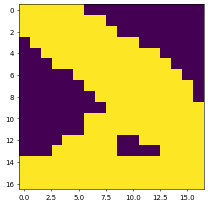

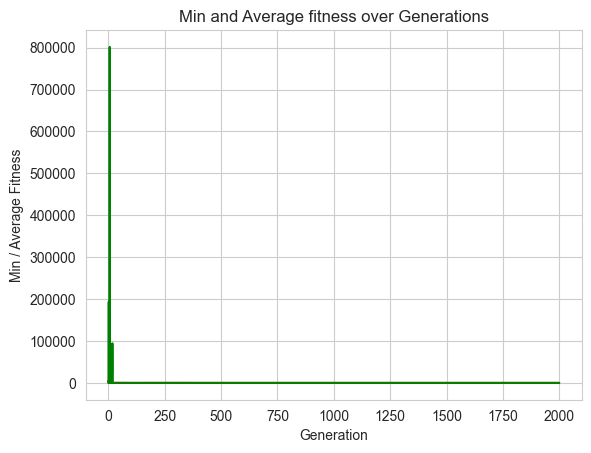

In [32]:
if __name__ == "__main__":
    start = time.time()
    top_ = main()
    end = time.time()  
    pool.close()   
    pool.join()

In [33]:
print('Total time taken: {} min'.format((end - start)/60))

Total time taken: 5.320640452702841 min


In [34]:
class Model:
    def __init__(self, x):
        self.flag_ = True
#         self.flag_ = False
        self.n, self.m = x.shape
        self.actions_dic={} 
        k=0
        for i in range(self.n):
            for j in range(self.m):
                if x[i][j]==1:
                    self.actions_dic[k]=(i,j)                        
                    k+=1  
        
    def action_space_(self, action, X):
        x,y=self.actions_dic[action]
        X[x][y]=1
        
    def draw(self,X):  
        plt.figure(dpi=50) 
        print('\nFinal Cantilever beam design:')
        plt.imshow(X) 
        plt.show()

In [35]:
def calculate_smoothness_metric(binary_matrix):
    """
    Calculates a smoothness metric for a 2D binary matrix.
    Lower values indicate greater smoothness. A value of 0 means 
    the image is perfectly uniform or has only linear transitions.

    The metric is the sum of differences between a pixel and its
    right and bottom neighbors, effectively counting vertical and
    horizontal edges.

    Args:
        binary_matrix (list of lists or numpy array): A 2D matrix 
                                                     with values 0 or 1.

    Returns:
        int: The total count of horizontal and vertical transitions.
    """
    # Convert to a numpy array for efficient processing
    matrix = np.array(binary_matrix, dtype=int)
    h, w = matrix.shape
    
    # Calculate absolute differences for horizontal transitions
    # We slice the matrix to compare each element with its right neighbor
    horizontal_diffs = np.abs(matrix[:, :w-1] - matrix[:, 1:])
    
    # Calculate absolute differences for vertical transitions
    # We slice the matrix to compare each element with its bottom neighbor
    vertical_diffs = np.abs(matrix[:h-1, :] - matrix[1:, :])
    
    # The sum of these differences gives the total number of transitions (edges)
    total_transitions = np.sum(horizontal_diffs) + np.sum(vertical_diffs)
    
    return int(total_transitions)

In [36]:
def count_islands_dfs(grid):
    """
    Calculates the number of islands in a 2D binary grid using Depth First Search (DFS).

    An island is formed by connected 1's (horizontally/vertically adjacent).
    
    Args:
        grid (list of lists): A 2D matrix with values 0 or 1.

    Returns:
        int: The total number of islands found.
    """
#     if not grid or not grid[0]:
#         return 0
    
    rows = len(grid)
    cols = len(grid[0])
    visited = set()
    island_count = 0

    def dfs(r, c):
        """Helper function to traverse and mark a single island as visited."""
        # Check boundary conditions and if the cell has already been visited or is water (0)
        if r < 0 or r >= rows or c < 0 or c >= cols or grid[r][c] == 0 or (r, c) in visited:
            return
        
        visited.add((r, c))
        
        # Recursively visit all adjacent cells (up, down, left, right)
        dfs(r + 1, c) # Down
        dfs(r - 1, c) # Up
        dfs(r, c + 1) # Right
        dfs(r, c - 1) # Left

    # Iterate through every cell in the grid
    for r in range(rows):
        for c in range(cols):
            # If we find land (1) that hasn't been visited yet, 
            # it means we've found the start of a new island.
            if grid[r][c] == 1 and (r, c) not in visited:
                island_count += 1
                # Start DFS from this point to mark all parts of this island
                dfs(r, c)
                
    return island_count

In [37]:
class CantileverEnv(gym.Env):
    
    metadata = {"render.modes": ["human"]}

    def __init__(self,topology, normalized_image: bool = False):
        super().__init__()
        
        
        self.rd=0
        self.args = get_args(*mbb_beam(rd=self.rd))
        

        self.topology=topology.copy()
    
        self.M = Model(self.topology)
        self.x = anp.ones((self.args.nely, self.args.nelx))*self.args.density 

        N_DISCRETE_ACTIONS=len(self.M.actions_dic)
        
        self.action_space = spaces.Discrete(N_DISCRETE_ACTIONS)
        self.observation_space = spaces.Box(low=0,
                                            high=255,
                                            shape=(self.args.nely, self.args.nelx, 1),
                                            dtype=np.float64)
        
        
        
        self.reward=0
        self.step_=0
        self.needs_reset = True
        
    def step(self, action):
        
        self.args = get_args(*mbb_beam(rd=self.rd))

        self.M.action_space_(action, self.x)

        self.step_+=1
               
        done=False
                  
        if self.step_>self.M.n*self.M.m:
            done=True
            
        const1=np.sum(self.x)/(x0*y0)   
        
        if const1>0.7:
            done=True
            
        if self.needs_reset:
            raise RuntimeError("Tried to step environment that needs reset")
            
        if done:
            tmp, const = fast_stopt(self.args, self.x)
            self.reward=1/tmp+1/calculate_smoothness_metric(self.x.reshape(y0,x0))
            if count_islands_dfs(self.x)==1:
                self.reward*=10
            self.needs_reset = True

        return self.x.reshape(x0,y0,1), self.reward, done, False, {}

    def reset(self, seed=0):
        
        if not self.M.flag_:
            self.rd=random.choice([0,2,-2])
        else:
            self.rd=-1
           
        self.x = anp.ones((self.args.nely, self.args.nelx))*self.args.density 

        self.reward=0
        self.needs_reset = False
        self.step_=0

        return self.x.reshape(x0,y0,1), {}

    def render(self, mode="human"):
        self.M.draw(self.x)    

    def close(self):
        pass

In [38]:
class SaveOnBestTrainingRewardCallback(BaseCallback):
    """
    Callback for saving a model (the check is done every ``check_freq`` steps)
    based on the training reward (in practice, we recommend using ``EvalCallback``).

    :param check_freq: (int)
    :param log_dir: (str) Path to the folder where the model will be saved.
      It must contains the file created by the ``Monitor`` wrapper.
    :param verbose: (int)
    """

    def __init__(self, check_freq: int, log_dir: str, verbose=1):
        super().__init__(verbose)
        self.check_freq = check_freq
        self.log_dir = log_dir
        self.save_path = os.path.join(log_dir, "best_model")
        self.best_mean_reward = -np.inf

    def _init_callback(self) -> None:
        # Create folder if needed
        if self.save_path is not None:
            os.makedirs(self.save_path, exist_ok=True)

    def _on_step(self) -> bool:
        if self.n_calls % self.check_freq == 0:

            # Retrieve training reward
            x, y = ts2xy(load_results(self.log_dir), "timesteps")
            if len(x) > 0:
                # Mean training reward over the last 100 episodes
                mean_reward = np.mean(y[-100:])
                if self.verbose > 0:
                    print(f"Num timesteps: {self.num_timesteps}")
                    print(
                        f"Best mean reward: {self.best_mean_reward:.2f} - Last mean reward per episode: {mean_reward:.2f}"
                    )

                # New best model, you could save the agent here
                if mean_reward > self.best_mean_reward:
                    self.best_mean_reward = mean_reward
                    # Example for saving best model
                    if self.verbose > 0:
                        print(f"Saving new best model to {self.save_path}.zip")
                    self.model.save(self.save_path)

        return True

In [39]:
ts=5e6

In [40]:
# Create log dir
log_dir = "/tmp/gym_gen_1_2bdkjdn4289uwww2/"
os.makedirs(log_dir, exist_ok=True)

# Create and wrap the environment
env = CantileverEnv(topology=top_)
# Logs will be saved in log_dir/monitor.csv
env = Monitor(env, log_dir)
check_env(env)

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/stable_baselines3/common/env_checker.py:67: UserWarning: It seems that your observation  is an image but its `dtype` is (float64) whereas it has to be `np.uint8`. If your observation is not an image, we recommend you to flatten the observation to have only a 1D vector
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/stable_baselines3/common/env_checker.py:88: UserWarning: The minimal resolution for an image is 36x36 for the default `CnnPolicy`. You might need to use a custom features extractor cf. https://stable-baselines3.readthedocs.io/en/master/guide/custom_policy.html
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.render_mode to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.render_mode` for 

In [41]:
callback = SaveOnBestTrainingRewardCallback(check_freq = 100_000, log_dir = log_dir)

In [42]:
start = time.time()
model = PPO("MlpPolicy", env).learn(total_timesteps=ts, callback=callback)
end = time.time()   

Num timesteps: 100000
Best mean reward: -inf - Last mean reward per episode: 0.22
Saving new best model to /tmp/gym_gen_1_2bdkjdn4289uwww2/best_model.zip
Num timesteps: 200000
Best mean reward: 0.22 - Last mean reward per episode: 0.23
Saving new best model to /tmp/gym_gen_1_2bdkjdn4289uwww2/best_model.zip
Num timesteps: 300000
Best mean reward: 0.23 - Last mean reward per episode: 0.21
Num timesteps: 400000
Best mean reward: 0.23 - Last mean reward per episode: 0.21
Num timesteps: 500000
Best mean reward: 0.23 - Last mean reward per episode: 0.22
Num timesteps: 600000
Best mean reward: 0.23 - Last mean reward per episode: 0.21
Num timesteps: 700000
Best mean reward: 0.23 - Last mean reward per episode: 0.23
Num timesteps: 800000
Best mean reward: 0.23 - Last mean reward per episode: 0.23
Saving new best model to /tmp/gym_gen_1_2bdkjdn4289uwww2/best_model.zip
Num timesteps: 900000
Best mean reward: 0.23 - Last mean reward per episode: 0.22
Num timesteps: 1000000
Best mean reward: 0.23 

In [43]:
print('Total time taken: {} min'.format((end - start)/60))

Total time taken: 47.423144733905794 min


### Inference

In [44]:
# env.M.flag_=True
env.M.flag_=False
obs=env.reset()
obs=obs[0]

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.M to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.M` for environment variables or `env.get_wrapper_attr('M')` that will search the reminding wrappers.
  logger.warn(


In [45]:
i=0
while i<2000:
    action, _states = model.predict(obs)
    obs, rewards, dones, _ , info = env.step(int(action))
    if dones: 
        break
    i+=1

In [46]:
print(i)

289


In [47]:
fast_stopt(env.args, env.x)

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.args to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.args` for environment variables or `env.get_wrapper_attr('args')` that will search the reminding wrappers.
  logger.warn(
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.x to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.x` for environment variables or `env.get_wrapper_attr('x')` that will search the reminding wrappers.
  logger.warn(


(51.87818386000004, 0.44642214532871977)


Final Cantilever beam design:


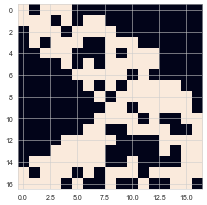

In [48]:
env.render()

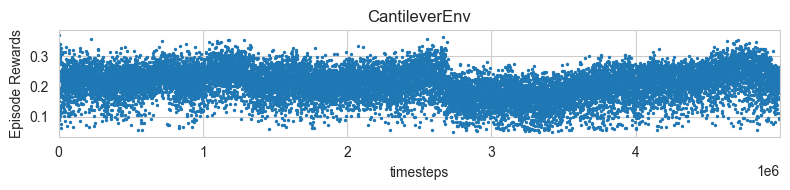

In [49]:
results_plotter.plot_results([log_dir], ts, results_plotter.X_TIMESTEPS, "CantileverEnv")

In [85]:
obs=env.reset()
obs=obs[0]

In [86]:
# Load the agent
model_best = PPO.load(log_dir + "best_model.zip", env=env)

In [87]:
i=0
while i<2000:
    action, _states = model_best.predict(obs)
    
    obs, rewards, dones, _ , info = env.step(int(action))
    if dones:
        break
    i+=1

In [88]:
i

289


Final Cantilever beam design:


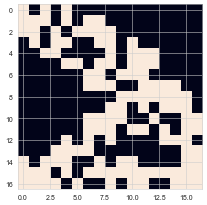

In [89]:
env.render()

In [90]:
# https://stable-baselines3.readthedocs.io/en/master/guide/save_format.html

In [91]:
fast_stopt(env.args, env.x)

(57.73256046037193, 0.42220311418685125)